# **Prediksi Stress Mahasiswa**

## **🖇️Project Overview**

Tekanan akademis merupakan salah satu pemicu utama masalah kesehatan mental di kalangan pelajar. Selain tekanan akademis, terdapat beberapa faktor lain yang mempengaruhi kondisi mental pelajar, seperti jam tidur, waktu terpapar oleh screen time, dukungan keluarga, dan lain sebagainya. Proyek ini bertujuan untuk **mendeteksi adanya indikasi stress pada mahasiswa** menggunakan algoritma **Random Forests, dan Naive Bayes** dengan dataset dari Kaggle.

👩🏻‍💻 **Manfaat Proyek:**

✔️ Meningkatkan kesadaran diri (Self-Awareness) mahasiswa untuk mengetahui apakah pola hidup, jam belajar, dan beban saat ini sudah masuk ke dalam zona bahaya terindikasi stress.

✔️ Mahasiswa dapat memanajemen waktu lebih baik.

✔️ Optimalisasi layanan konseling, dosen pembimbing akademik atau unit konseling kampus dapat memprioriatskan mahasiswa yang membutuhkan bantuan psikologis secara tepat sasaran dengan adanya sistem deteksi indikasi stress ini.


## **📄Business Understanding**

✒️ Problem Statements
1. Apa faktor yang paling mempengaruhi adanya indikasi stress pada mahasiswa?
2. Bagaimana machine learning dapat mendeteksi adanya indikasi stress pada mahasiswa?
3. Bagaimana performa model Random Forests dan Naive Bayes dalam klasifikasi indikasi stress pada mahasiswa?

🎯 **Goals**

✔️ Mengetahui faktor yang paling mempengaruhi adanya indikasi stress pada mahasiswa.

✔️ Mengembangkan sistem klasifikasi indikasi mahasiswa menggunakan machine learning.

✔️ Menguji performa model supervised learning, algoritma Random Forests dan Naive Bayes.





## 🔍**Data Understanding**
Dataset bersumber dari [kaggle](https://www.kaggle.com/datasets/sridevilavanyacse/student-lifestyle-and-stress-prediction-dataset)

Terdapat 25500 baris data dan sembilan kolom

### ▶️ **Install and Import Libraries**

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split # Memisah data
from sklearn.preprocessing import LabelEncoder # Mengubah teks jadi
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay # Untuk mengukur hasil
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
import kagglehub
import os

### ▶️ **Load Dataset from Google Drive**

In [26]:
path = kagglehub.dataset_download("sridevilavanyacse/student-lifestyle-and-stress-prediction-dataset")

print("Path to dataset files:", path)
print("Isi folder:", os.listdir(path))

file_name = "student-lifestyle-and-stress-dataset.csv"

full_path = os.path.join(path, file_name)

data = pd.read_csv(full_path)

df = data.copy()

Using Colab cache for faster access to the 'student-lifestyle-and-stress-prediction-dataset' dataset.
Path to dataset files: /kaggle/input/student-lifestyle-and-stress-prediction-dataset
Isi folder: ['student-lifestyle-and-stress-dataset.csv']


### ▶️ **Lihat Jumlah Baris Dan Kolom**

In [27]:
# Jumlah Baris dan Kolom

df.shape

(25500, 9)

🤔 Berikut adalah penjelasan untuk setiap kolom dalam dataset:

*   **Student_Type**: Menunjukkan kategori siswa. Ini adalah variabel kategorikal.
*   **Sleep_Hours**: Jumlah jam tidur siswa.
*   **Study_Hours**: Jumlah jam belajar siswa.
*   **Social_Media_Hours**: Jumlah jam siswa menghabiskan waktu di media sosial.
*   **Attendance**: Persentase kehadiran siswa.
*   **Exam_Pressure**: Tingkat tekanan yang dirasakan siswa terkait ujian.
*   **Family_Support**: Tingkat dukungan keluarga yang dirasakan siswa.
*   **Month**: Bulan saat data dikumpulkan atau relevan.
*   **Stress_Level**: Tingkat stres siswa. Ini adalah target variabel kita, bersifat biner (0 untuk tidak stres, 1 untuk stres) atau skala kategorikal.

### ▶️ **Lihat Data Kolom**

In [28]:
df.info()

df_stress = df.groupby('Stress_Level')['Stress_Level'].count().reset_index(name='Tingkat Stress')
df_stress

df_type = df.groupby('Student_Type')['Student_Type'].count().reset_index(name='Student Total')
df_type

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25500 entries, 0 to 25499
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Student_Type        24248 non-null  object 
 1   Sleep_Hours         24167 non-null  float64
 2   Study_Hours         24223 non-null  float64
 3   Social_Media_Hours  24188 non-null  float64
 4   Attendance          24195 non-null  float64
 5   Exam_Pressure       24230 non-null  float64
 6   Family_Support      24209 non-null  float64
 7   Month               24186 non-null  float64
 8   Stress_Level        25500 non-null  int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 1.8+ MB


,Student_Type,Student Total
0,college,13391
1,school,6021
2,working_student,4836


### 😖**Kondisi Data**
- Saat ini ada 24 data duplikat
- Banyak baris yang memiliki *missing values*
- Terdapata *Outlier* dengan mahasiswa yang jam tidurnya lebih kecil dari 3 jam

### ▶️ **Lihat Kondisi Data**

In [29]:
print("=== 🔴 KONDISI SEBELUM PEMBERSIHAN (RAW DATA) ===")
print(f"Total Baris: {len(data)}")
print(f"Jumlah Duplikat: {data.duplicated().sum()}")
print("\nJumlah Missing Values per Kolom:")
print(data.isnull().sum())

print("\nStatistik Deskriptif:")
display(data.describe())

=== 🔴 KONDISI SEBELUM PEMBERSIHAN (RAW DATA) ===
Total Baris: 25500
Jumlah Duplikat: 24

Jumlah Missing Values per Kolom:
Student_Type          1252
Sleep_Hours           1333
Study_Hours           1277
Social_Media_Hours    1312
Attendance            1305
Exam_Pressure         1270
Family_Support        1291
Month                 1314
Stress_Level             0
dtype: int64

Statistik Deskriptif:


,Sleep_Hours,Study_Hours,Social_Media_Hours,Attendance,Exam_Pressure,Family_Support,Month,Stress_Level
count,24167.000000,24223.000000,24188.000000,24195.000000,24230.000000,24209.000000,24186.000000,25500.000000
mean,6.458948,4.696477,3.555614,81.270961,5.369748,5.798298,6.500992,0.299882
std,1.504228,2.240148,1.901528,12.052045,2.394003,2.232371,3.455308,0.458215
min,2.008586,-1.433434,0.000040,-5.000000,1.000000,1.000000,1.000000,0.000000
25%,5.438360,3.078230,2.152249,73.738894,4.000000,4.000000,3.000000,0.000000
50%,6.542566,4.538138,3.500709,81.942959,5.000000,6.000000,6.000000,0.000000
75%,7.531571,6.135670,4.864312,90.106859,7.000000,7.000000,10.000000,1.000000
max,9.997527,22.444460,9.962134,120.000000,10.000000,10.000000,12.000000,1.000000


### 📊 **Eksplorasi Data Mentah (EDA - Pre-Cleaning)**

Sebelum kita melakukan pembersihan, mari kita bedah bagaimana rupa data ini sebenarnya. Memahami data mentah membantu kita memvalidasi apakah proses pembersihan nantinya benar-benar diperlukan.

### ▶️ **Melihat Korelasi Antar Fitur dengan Heatmap**

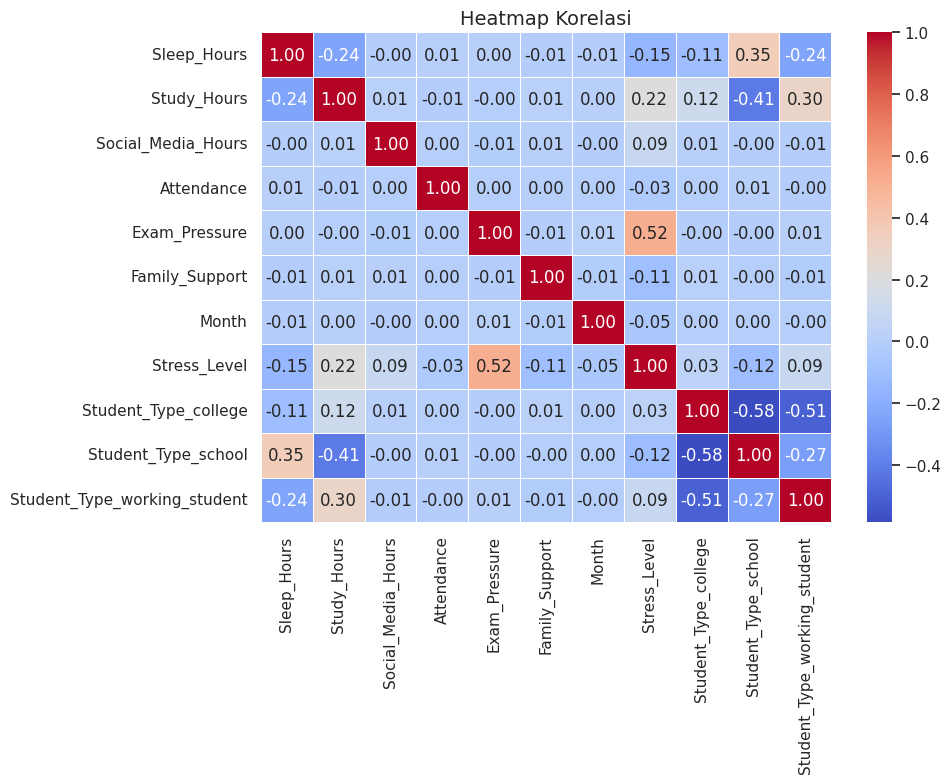

Nilai mendekati +1 = hubungan positif kuat
Nilai mendekati 0 = tidak ada hubungan
Nilai mendekati -1 = hubungan negatif kuat


In [30]:
df_encoded = pd.get_dummies(df, columns=['Student_Type'], dtype=int)

corr = df_encoded.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Heatmap Korelasi", fontsize=14)
plt.tight_layout()
plt.show()

print('Nilai mendekati +1 = hubungan positif kuat')
print('Nilai mendekati 0 = tidak ada hubungan')
print('Nilai mendekati -1 = hubungan negatif kuat')



#### 🔍 **Penjelasan Heatmap:**

Rentang nilai korelasi dengan kekuatan hubungan didasarkan pada:

0.00 - 0.19 = Sangat Lemah

0.20 - 0.39 = Lemah

0.40 - 0.59 = Sedang

0.60 - 0.79 = Kuat

0.80 - 1.00 = Sangat Kuat

Berikut merupakan analisis korelasi antar fitur dengan indikasi stress berdasarkan heatmap di atas:

1. Sleep_Hours (-0.14) = Korelasi negatif sangat lemah, bertambahnya jam tidur memiliki kecendrungan menurunkan indikasi stress, tetapi efeknya tidak signifikan.
2. Study_Hours (0.21) = Korelasi positif Lemah, bertambahnya jam belajar meningkatkan indikasi stress, tetapi efeknya kurang signifikan.
3. Social_Media_Hours (0.09) = Korelasi positif sangat lemah, bertambahnya jam scroll sosmed memiliki kecendrungan menaikkan indikasi stress, tetapi efeknya tidak signifikan.
4. Attendance (-0.03) = Korelasi negatif sangat lemah, banyaknya persentase kehadiran mahasiswa memiliki kecendrungan menurunkan indikasi stress, tetapi efeknya tidak signifikan.
5. Exam_Pressure (0.51) = Korelasi positif sedang, bertambahnya tekanan ujian mahasiswa menaikkan indikasi stress
6. Family_Support (-0.10) = Korelasi negatif sangat lemah, bertambahnya dukungan keluarga dapat menurunkan indikasi stress
7. Month (-0.05) = Korelasi negatif sangat lemah

### ▶️ **Melihat Distribusi Data**

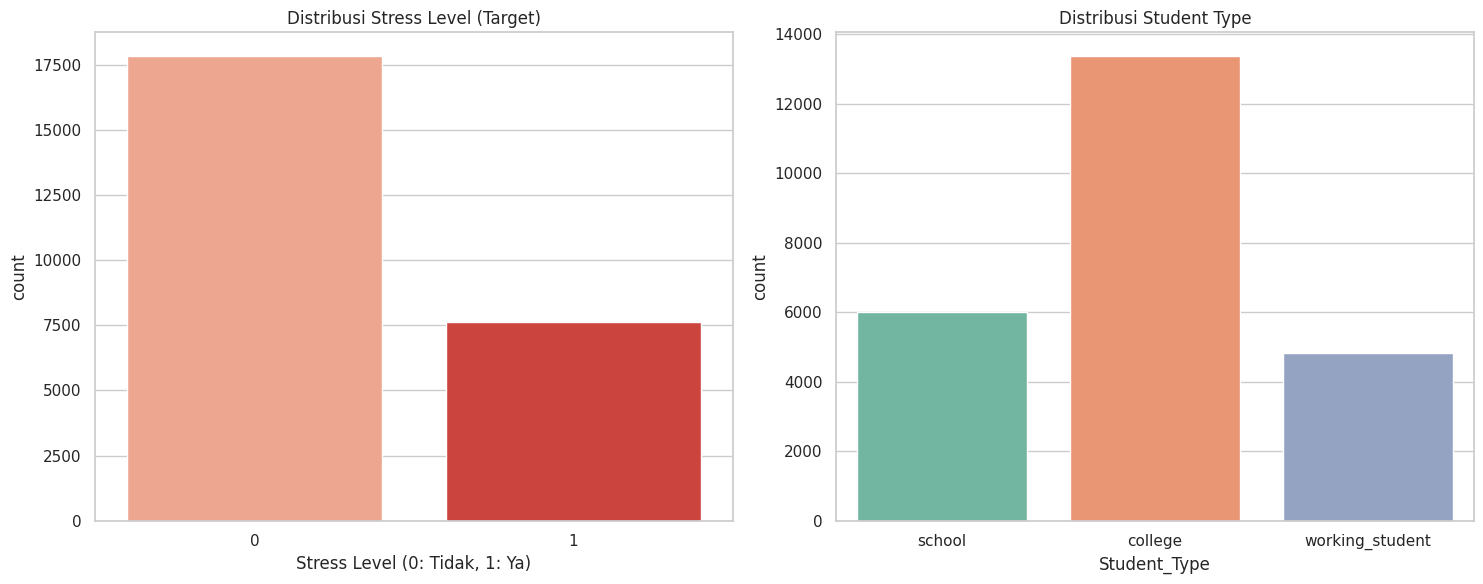

In [31]:
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.countplot(data=data, x='Stress_Level', ax=axes[0], hue='Stress_Level', palette='Reds', legend=False)
axes[0].set_title('Distribusi Stress Level (Target)')
axes[0].set_xlabel('Stress Level (0: Tidak, 1: Ya)')

sns.countplot(data=data, x='Student_Type', ax=axes[1], hue='Student_Type', palette='Set2', legend=False)
axes[1].set_title('Distribusi Student Type')

plt.tight_layout()
plt.show()

### 🔍 **Wawasan Utama Data Mentah:**

*   **Imbalance Target**: Jumlah mahasiswa yang *tidak stress* jauh lebih banyak dibandingkan yang *stress*. Ini penting untuk diperhatikan saat melatih model machine learning nanti.
*   **Data Bolong (Missing)**: Grafik di atas belum mencerminkan total populasi 25.500 karena banyaknya nilai NaN.
*   **Pola Belajar vs Tidur**: Mari kita lihat bagaimana sebaran jam belajar dan jam tidur sebelum dibersihkan (termasuk outlier).

### ▶️ **Melihat Sebaran Jam Tidur dan Jam Belajar**

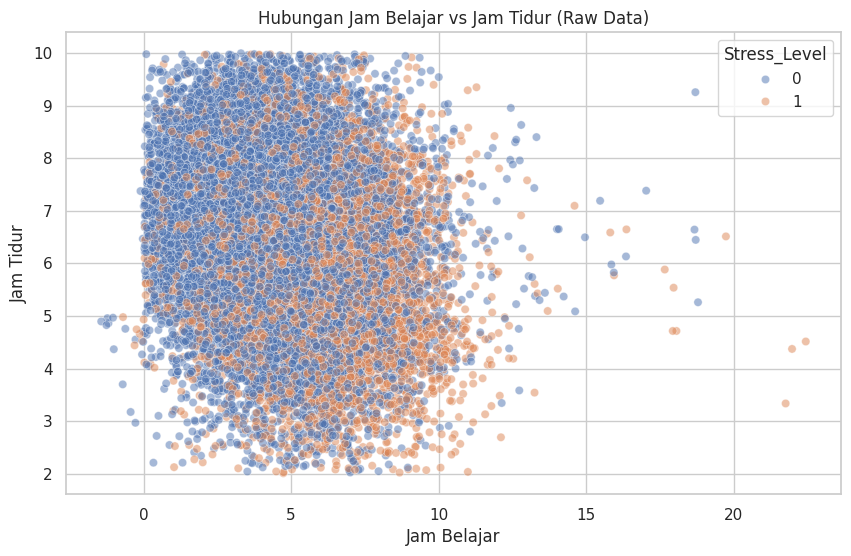

In [32]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x='Study_Hours', y='Sleep_Hours', hue='Stress_Level', alpha=0.5)
plt.title('Hubungan Jam Belajar vs Jam Tidur (Raw Data)')
plt.xlabel('Jam Belajar')
plt.ylabel('Jam Tidur')
plt.show()

## 🖊**Data Preparation**
Dalam *data preparation*, kita akan menghapus data duplikat, membenarkan data dengan *missing values*, dan data *Outlier*

### 👓**Mencari *Outlier***
Untuk mendeteksi *outlier*, kita bisa memvisualisasikan distribusi data menggunakan *boxplot* untuk kolom numerik. Ini akan membantu kita melihat nilai-nilai yang jauh dari sebagian besar data.

### ▶️ **Mencari Data *Outlier***

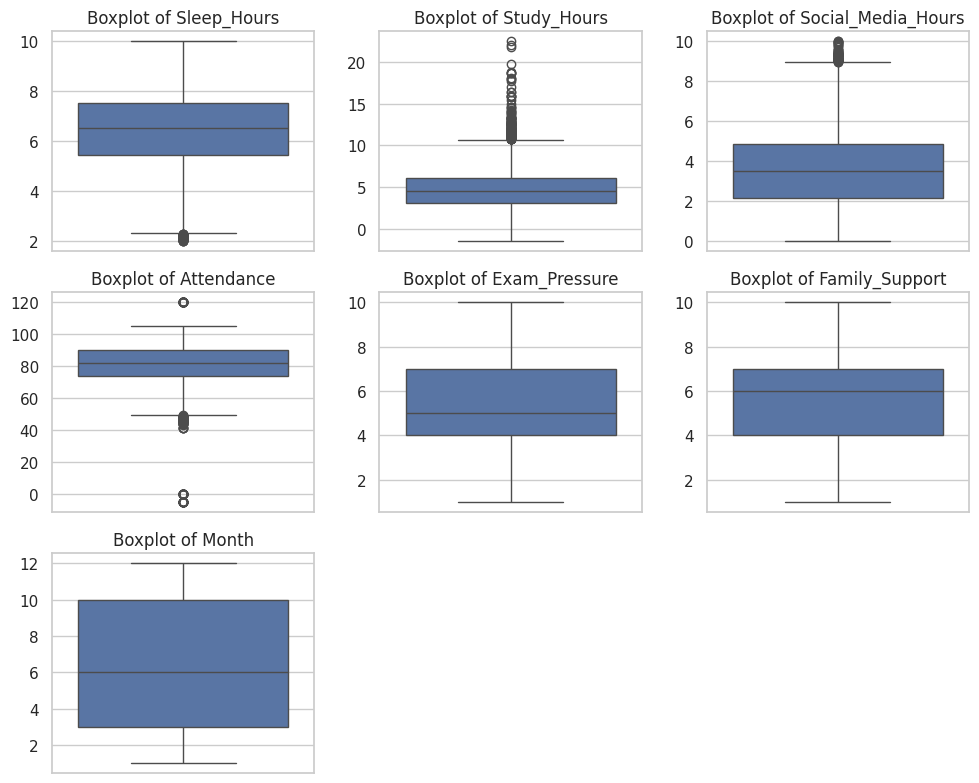

In [33]:
numerical_cols = ['Sleep_Hours', 'Study_Hours', 'Social_Media_Hours', 'Attendance', 'Exam_Pressure', 'Family_Support', 'Month']

plt.figure(figsize=(10, 8))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
    plt.ylabel('')
plt.tight_layout()
plt.show()

### ▶️ **Menghapus Data Duplikat**

In [34]:
df.drop_duplicates(inplace=True)
print(f"Jumlah data setelah menghapus duplikat: {len(df)}")

Jumlah data setelah menghapus duplikat: 25476


### ▶️ **Memperbaiki *Missing Values***
Untuk memperbaiki *missing values*, kita akan mengisi data yang tidak memiliki nilai dengan nilai median dari kolom tersebut jika kolom menggunakan tipe data numerik. Jika kolom yang memiliki *missing values* adalah data yang bertipe kategori maka akan kita isi dengan modus dari kolom tersebut

In [35]:
for col in numerical_cols:
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)

if df['Student_Type'].isnull().any():
    mode_val = df['Student_Type'].mode()[0]
    df['Student_Type'].fillna(mode_val, inplace=True)

print("\nJumlah missing values setelah imputasi:")
print(df.isnull().sum())


Jumlah missing values setelah imputasi:
Student_Type          0
Sleep_Hours           0
Study_Hours           0
Social_Media_Hours    0
Attendance            0
Exam_Pressure         0
Family_Support        0
Month                 0
Stress_Level          0
dtype: int64


/tmp/ipykernel_2320/2026512743.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_val, inplace=True)
/tmp/ipykernel_2320/2026512743.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'd

### ▶️ **Menangani Outlier**
Kita akan menghapus baris data di mana nilai-nilai numerik (seperti jam tidur, jam belajar, dll.) berada di bawah 0, karena nilai-nilai negatif pada konteks ini dianggap sebagai *outlier* yang tidak valid.

In [36]:
initial_rows = len(df)

for col in numerical_cols:
    if (df[col] < 0).any():
        df = df[df[col] >= 0]
        print(f"Removed rows with {col} < 0. Current rows: {len(df)}")

print(f"\nJumlah baris setelah menghapus outlier: {len(df)}")
print(f"Total baris outlier yang dihapus: {initial_rows - len(df)}")

Removed rows with Study_Hours < 0. Current rows: 25455
Removed rows with Attendance < 0. Current rows: 25426

Jumlah baris setelah menghapus outlier: 25426
Total baris outlier yang dihapus: 50


### **🔍 Hasil Quality Check Data**

Setelah dilakukan penelusuran mendalam, berikut adalah rangkuman kondisi kesehatan dataset kita:

### **1. 📝 Missing Values (Data Hilang)**
*   **Status:** 🛠️ *Fixed!*
*   **Temuan Awal:** Terdapat sekitar ~1.300 data kosong di hampir setiap kolom numerik dan kategori.
*   **Tindakan:**
    *   Kolom **Numerik** (Sleep, Study, dll) diisi menggunakan nilai tengah (**Median**).
    *   Kolom **Kategori** (Student Type) diisi menggunakan nilai terbanyak (**Modus**).
*   **Hasil Akhir:** 0 Missing Values! ✅

### **2. 👥 Data Duplikat**
*   **Status:** 🧹 *Cleaned!*
*   **Temuan:** Terdeteksi **24 baris** data yang identik (duplikat).
*   **Tindakan:** Seluruh baris duplikat telah dihapus untuk menjaga keaslian analisis.
*   **Hasil Akhir:** Dataset kini bersih dari data ganda! ✨

### **3. 📈 Outliers (Data Pencilan)**
*   **Status:** ⚠️ *Identified*
*   **Temuan Menarik:**
    *   😴 **Sleep Hours:** Ada siswa yang tidur kurang dari 3 jam!
    *   📚 **Study Hours:** Ditemukan siswa 'super' yang belajar lebih dari 15-20 jam!
    *   📱 **Social Media:** Ada yang menghabiskan waktu >9 jam sehari.
    *   🏫 **Attendance:** Ada data kehadiran yang sangat rendah (0-40%).
    * **Nilai Negatif:** Pada Study Hours dan Attendance terdapat nilai minimum negatif.
*   **Catatan:** Outlier ini tetap dipertahankan untuk sementara karena mungkin mencerminkan kondisi riil mahasiswa yang ekstrem sebelum masuk ke tahap pemodelan. Kecuali untuk data yang mengandung nilai negatif seperti pada poin ke-5.

### **📊 Laporan Perbandingan Kualitas Data**

Mari kita bandingkan kondisi data antara sebelum dilakukan pembersihan dan sesudah pembersihan.

In [37]:
print("=== 🟢 KONDISI SESUDAH PEMBERSIHAN (CLEANED DATA) ===")
print(f"Total Baris: {len(df)}")
print(f"Jumlah Duplikat: {df.duplicated().sum()}")
print("\nJumlah Missing Values per Kolom:")
print(df.isnull().sum())

print("\nStatistik Deskriptif:")
display(df.describe())

=== 🟢 KONDISI SESUDAH PEMBERSIHAN (CLEANED DATA) ===
Total Baris: 25426
Jumlah Duplikat: 0

Jumlah Missing Values per Kolom:
Student_Type          0
Sleep_Hours           0
Study_Hours           0
Social_Media_Hours    0
Attendance            0
Exam_Pressure         0
Family_Support        0
Month                 0
Stress_Level          0
dtype: int64

Statistik Deskriptif:


,Sleep_Hours,Study_Hours,Social_Media_Hours,Attendance,Exam_Pressure,Family_Support,Month,Stress_Level
count,25426.000000,25426.000000,25426.000000,25426.000000,25426.000000,25426.000000,25426.000000,25426.000000
mean,6.464266,4.692252,3.552018,81.401320,5.350035,5.808070,6.475930,0.299811
std,1.464358,2.179811,1.851428,11.379860,2.335083,2.175481,3.366909,0.458184
min,2.008586,0.004503,0.000040,0.000000,1.000000,1.000000,1.000000,0.000000
25%,5.513730,3.159934,2.234670,74.314332,4.000000,4.000000,4.000000,0.000000
50%,6.542207,4.538138,3.501057,81.941554,5.000000,6.000000,6.000000,0.000000
75%,7.475712,6.035808,4.774084,89.595160,7.000000,7.000000,9.000000,1.000000
max,9.997527,22.444460,9.962134,120.000000,10.000000,10.000000,12.000000,1.000000


###▶️ **Drop Baris dengan Student_Type = school**

In [38]:
df = df[df['Student_Type'] != 'school']

df_type = df.groupby('Student_Type')['Student_Type'].count().reset_index(name='Student Total')
df_type

,Student_Type,Student Total
0,college,14599
1,working_student,4823


###▶️ **Membulatkan Angka Jam dengan Pembulatan Terdekat**

In [39]:
df['Sleep_Hours'] = df['Sleep_Hours'].round(0).astype(int)
df['Study_Hours'] = df['Study_Hours'].round(0).astype(int)
df['Social_Media_Hours'] = df['Social_Media_Hours'].round(0).astype(int)
df['Exam_Pressure'] = df['Exam_Pressure'].round(0).astype(int)
df['Family_Support'] = df['Family_Support'].round(0).astype(int)

### ▶️ **Label Encoding untuk Student Type**

In [40]:
le = LabelEncoder()

df['Student_Type_Encoded'] = le.fit_transform(df['Student_Type'])

print('Hasil Encoding Student Type') # 0 = College, 1 = Working_Student
print(df[['Student_Type', 'Student_Type_Encoded']])
print(df['Student_Type_Encoded'].value_counts())


Hasil Encoding Student Type
          Student_Type  Student_Type_Encoded
2              college                     0
4              college                     0
5              college                     0
6              college                     0
7              college                     0
...                ...                   ...
25493  working_student                     1
25494          college                     0
25495          college                     0
25497          college                     0
25499          college                     0

[19422 rows x 2 columns]
Student_Type_Encoded
0    14599
1     4823
Name: count, dtype: int64


In [41]:
df.sample()

,Student_Type,Sleep_Hours,Study_Hours,Social_Media_Hours,Attendance,Exam_Pressure,Family_Support,Month,Stress_Level,Student_Type_Encoded
4558,college,8,3,1,88.776934,6,8,10.0,0,0


In [42]:
# Menentukan kolom INPUT (X) dan kolom TARGET (y)

X = df[['Student_Type_Encoded', 'Sleep_Hours', 'Study_Hours', 'Social_Media_Hours', 'Exam_Pressure', 'Family_Support']]
y = df['Stress_Level']

print('Kolom INPUT (X):')
print(X.head(3))
print()
print('Kolom TARGET (Y):')
print(y.head(3).to_string())

Kolom INPUT (X):
   Student_Type_Encoded  Sleep_Hours  Study_Hours  Social_Media_Hours  \
2                     0            4            6                   3   
4                     0            5            9                   8   
5                     0            5            5                   2   

   Exam_Pressure  Family_Support  
2              7               1  
4              5               6  
5              3               5  

Kolom TARGET (Y):
2    1
4    1
5    0


###▶️ **Training dan Testing**

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f'Data Training : {len(X_train)} baris <- untuk melatih model')
print(f'Data Testing : {len(X_test)} baris <- untuk menguji model')

Data Training : 15537 baris <- untuk melatih model
Data Testing : 3885 baris <- untuk menguji model


### **📝 Ringkasan Perubahan:**

1.  **Baris Data**: Berkurang dari **25.500** menjadi **25.476** karena penghapusan duplikat.
2.  **Missing Values**: Berhasil dibersihkan dari ~1.300 data kosong menjadi **0 (Nol)**.
3. **Drop Baris**: Drop baris yang Student_Type nya sama dengan 'school' karena data yang dibutuhkan hanyalah mahasiswa. Sehingga, baris data saat ini yaitu **19.464**.
4.  **Integritas Data**: Nilai rata-rata dan distribusi sekarang lebih akurat untuk proses permodelan selanjutnya.
5. **Pembulatan Angka**: Pada data yang merupakan jam dan skala, dilakukan pembulatan terdekat menggunakan fungsi round().
5. **Label Encoding**: Perubahan Student_Type dilakukan dengan mengubah tipe data string menjadi integer, lebih tepatnya menjadi label 0 dan 1.

## **Modelling**

In [44]:
## Model Random Forests

model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

model_nb = GaussianNB()
model_nb.fit(X_train, y_train)
## Model Naive Bayes
print('Model selesai dilatih!')



Model selesai dilatih!


## **Model Evaluation**

In [45]:
target_name = ['Tidak Stress', 'Stress']

y_pred_rf = model_rf.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
classification_rep_rf = classification_report(y_test, y_pred_rf, target_names=target_name)

y_pred_nb = model_nb.predict(X_test)
accuracy_nb = accuracy_score(y_test, y_pred_nb)
classification_rep_nb = classification_report(y_test, y_pred_nb, target_names=target_name)

print(f"Model Random Forests Accuracy: {accuracy_rf*100:.2f}%")
print("\nClassification Report Random Forests:\n", classification_rep_rf)
print(f"Model Gaussian Naive Bayes Accuracy: {accuracy_nb*100:.2f}%")
print("\nClassification Report Naive Bayes:\n", classification_rep_nb)

Model Random Forests Accuracy: 76.96%

Classification Report Random Forests:
               precision    recall  f1-score   support

Tidak Stress       0.82      0.85      0.83      2627
      Stress       0.66      0.60      0.63      1258

    accuracy                           0.77      3885
   macro avg       0.74      0.73      0.73      3885
weighted avg       0.77      0.77      0.77      3885

Model Gaussian Naive Bayes Accuracy: 79.79%

Classification Report Naive Bayes:
               precision    recall  f1-score   support

Tidak Stress       0.83      0.89      0.86      2627
      Stress       0.72      0.61      0.66      1258

    accuracy                           0.80      3885
   macro avg       0.77      0.75      0.76      3885
weighted avg       0.79      0.80      0.79      3885



In [46]:
# Lihat beberapa contoh hasil prediksi vs jawaban asli

## Random Forests
contoh_rf = X_test.copy().reset_index(drop=True)
contoh_rf['Indikasi Stress Asli']    = [target_name[l] for l in y_test.values]
contoh_rf['Indikasi Stress Prediksi'] = [target_name[l] for l in y_pred_rf]
contoh_rf['Benar?'] = ['✅' if a == p else '❌' for a, p in zip(y_test.values, y_pred_rf)]

contoh_nb = X_test.copy().reset_index(drop=True)
contoh_nb['Indikasi Stress Asli']    = [target_name[l] for l in y_test.values]
contoh_nb['Indikasi Stress Prediksi'] = [target_name[l] for l in y_pred_nb]
contoh_nb['Benar?'] = ['✅' if a == p else '❌' for a, p in zip(y_test.values, y_pred_nb)]

print('10 Contoh Hasil Prediksi Random Forests:')
print(contoh_rf[['Indikasi Stress Asli', 'Indikasi Stress Prediksi', 'Benar?']].head(10).to_string())

print('\n10 Contoh Hasil Prediksi Naive Bayes:')
print(contoh_nb[['Indikasi Stress Asli', 'Indikasi Stress Prediksi', 'Benar?']].head(10).to_string())

10 Contoh Hasil Prediksi Random Forests:
  Indikasi Stress Asli Indikasi Stress Prediksi Benar?
0         Tidak Stress             Tidak Stress      ✅
1         Tidak Stress                   Stress      ❌
2         Tidak Stress                   Stress      ❌
3               Stress             Tidak Stress      ❌
4         Tidak Stress                   Stress      ❌
5         Tidak Stress                   Stress      ❌
6         Tidak Stress             Tidak Stress      ✅
7         Tidak Stress             Tidak Stress      ✅
8         Tidak Stress             Tidak Stress      ✅
9         Tidak Stress             Tidak Stress      ✅

10 Contoh Hasil Prediksi Naive Bayes:
  Indikasi Stress Asli Indikasi Stress Prediksi Benar?
0         Tidak Stress             Tidak Stress      ✅
1         Tidak Stress                   Stress      ❌
2         Tidak Stress             Tidak Stress      ✅
3               Stress                   Stress      ✅
4         Tidak Stress             Tidak

<Figure size 600x500 with 0 Axes>

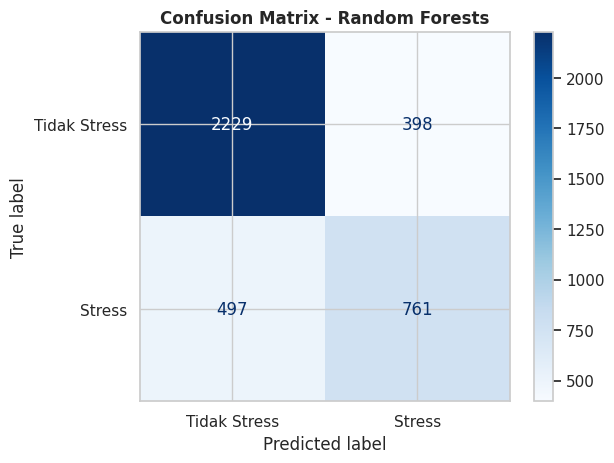

In [47]:
# Confusion Matrix Random Forests

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Tidak Stress', 'Stress'])
disp.plot(cmap='Blues', values_format='d')

plt.title('Confusion Matrix - Random Forests', fontsize=12, fontweight='bold')
plt.show()

<Figure size 600x500 with 0 Axes>

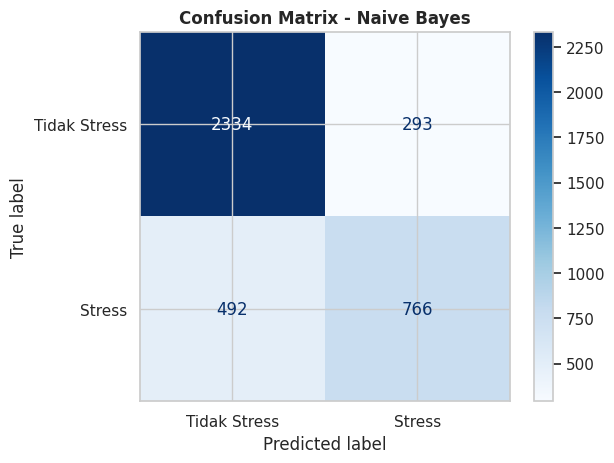

In [48]:
# Confusion Matrix Random Forests

cm_nb = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=['Tidak Stress', 'Stress'])
disp.plot(cmap='Blues', values_format='d')

plt.title('Confusion Matrix - Naive Bayes', fontsize=12, fontweight='bold')
plt.show()

## **Deployment**

Deployment model dapa dilihat pada link di bawah ini:
https://huggingface.co/spaces/arbinnn/student_stress

### **Analisis Ketidakseimbangan Data**

Kedua model memiliki performa yang jauh lebih baik dalam memprediksi kelas 'Tidak Stress' (contohnya F1-score 0.86 pada Naive Bayes) dibandingkan kelas 'Stress' (F1-score: 0.66 pada Naive Bayes). Hal ini dipengaruhi oleh jumlah sampel data training kelas 'Tidak Stress' yang dua kali lipat lebih banyak daripada kelas 'Stress' (support 2627 vs 1258). Efeknya, model lebih kaya akan informasi mengenai karakteristik mahasiswa yang tidak stres.

### **Precision vs Recall**

Precision Kelas Stress (Random Forests) = 0.66: Dari semua mahasiswa yang diprediksi stres oleh Naive Bayes, 66% dari mereka aslinya memang terindikasi stres.

Precision Kelas Stress (Naive Bayes) = 0.72: Dari semua mahasiswa yang diprediksi stres oleh Naive Bayes, 72% dari mereka aslinya memang terindikasi stres.

Recall Kelas Stress (Random Forests) = 0.60: Dari total seluruh mahasiswa yang aslinya stres di dunia nyata, Naive Bayes hanya berhasil mendeteksi 60% di antaranya (40% lolos tidak terdeteksi).

Recall Kelas Stress (Naive Bayes) = 0.61: Dari total seluruh mahasiswa yang aslinya stres di dunia nyata, Naive Bayes hanya berhasil mendeteksi 61% di antaranya (39% lolos tidak terdeteksi).

## **Kesimpulan**

Berdasarkan pemodelan yang telah dilakukan sebelumnya, dapat dilihat bahwa model Gaussian Naive Bayes menunjukkan performa yang lebih unggul dengan akurasi sebesar  79.79% atau dibulatkan menjadi 79.8%, dibandingkan dengan model Random Forests yang menghasilkan akurasi 76.96%. Keunggulan Naive Bayes pada dataset ini mengindikasikan bahwa fitur-fitur indikator gaya hidup mahasiswa dan faktor lainnya merupakan distribusi yang cenderung independen secara kondisional terhadap variabel target indikasi stress.

/tmp/ipykernel_2320/3350591204.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=models, y=accuracies, palette=['#bfdbfe', '#2563eb'])


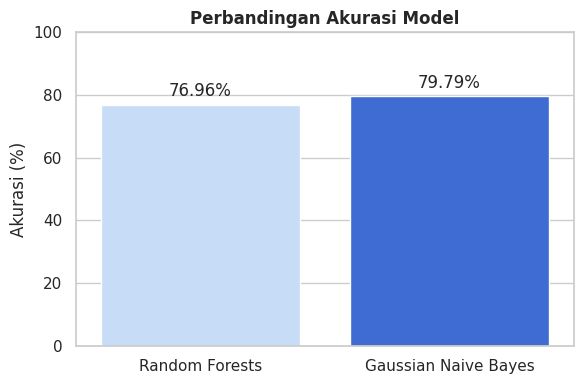

In [49]:
# Visualisasi

models = ['Random Forests', 'Gaussian Naive Bayes']
accuracies = [accuracy_rf * 100, accuracy_nb * 100]

plt.figure(figsize=(6,4))
ax = sns.barplot(x=models, y=accuracies, palette=['#bfdbfe', '#2563eb'])

for bars in ax.containers:
    ax.bar_label(bars, fmt='%.2f%%', label_type='edge', padding=3)

plt.ylim(0, 100)
plt.title('Perbandingan Akurasi Model', fontsize=12, fontweight='bold')
plt.ylabel('Akurasi (%)')
plt.tight_layout()
plt.show()